# TRAINING AND ASSESSING THE MODELS

For this notebook please make sure that in *./csv/datasets* there are the following files:
- csv/datasets/nifh_dataset.csv
- csv/datasets/nifh_dataset_simple_tr.csv
- csv/datasets/nifh_dataset_simple_tr_out.csv
- csv/datasets/nifh_dataset_scikit_0.csv
- csv/datasets/nifh_dataset_scikit_2.csv

## Libraries

In [333]:
import sys
print(sys.executable)

/usr/bin/python


In [334]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib
import seaborn as sns
import joblib as joblib
from sklearn.metrics import mean_absolute_error

## Column names are stored 

In [335]:
x_columns = ['O2_knn', 'T_knn', 'N_knn', 'P_knn', 'Fe_knn', 'solar_knn']
y_columns =['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

## Functions

In [336]:
def plotColsOnMap(cols,df, log_range = False, mult = 1):
    #the index is reset from using lat and lon just in case
    df_reset = df.reset_index()

    #the number of rows varies depending on the number of columns to plot
    rows = (len(cols)//2) + (len(cols)%2==1)

    #a set of subplots is created
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4), subplot_kw={"projection": ccrs.PlateCarree()})

    #we plot each column
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]#subplot

        #we want to see the coastlines on the globe and only take not null values
        ax.add_feature(cfeature.COASTLINE)
        valid_data = df_reset[df_reset[col].notna()]
        
        #this sets the logorithmic scale to be exactly like in the paper instead of default
        norm = matplotlib.colors.LogNorm(vmin=1e3, vmax=1e11)
        if(not log_range):
            norm = None

        #scatter plot is created
        sc = ax.scatter(
            valid_data["LONGITUDE"],
            valid_data["LATITUDE"],
            c=valid_data[col]*mult,
            cmap="viridis",
            s=40,
            transform=ccrs.PlateCarree(),
            norm=norm
        )

        #we want to see the entire globe and not just the values 
        ax.set_xlim(-180,180)
        ax.set_ylim(-90,90)

        label = "nifH Gene (copies m-3" if "nifH Gene (copies m-3)" in col else ""

        plt.colorbar(sc, ax=ax, label=label)
        ax.set_title(col.replace("x106 ",""))

    plt.tight_layout()
    plt.show()

In [337]:
def histCols(cols,df, log_range = False, transf = (lambda x: x), suptitle=""):
    #the index is reset from using lat and lon just in case
    df_reset = df.reset_index()

    #the number of rows varies depending on the number of columns to plot
    rows = (len(cols)//2) + (len(cols)%2==1)

    #a set of subplots is created
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4))

    #we plot each column
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]#subplot

        valid_data = df_reset[df_reset[col].notna()]
        transf(valid_data[col]).hist(bins=50, ax=ax)

        ax.set_title(col)

    
    if(len(suptitle)>0):
        plt.suptitle(suptitle, fontsize=16)

    plt.tight_layout()
    plt.show()

In [338]:
def getData(feature, dataset):
    return dataset.dropna(subset=feature, how='all')[x_columns+y_columns]

In order to make testing different models easier I created a function for that purpose. 

In [339]:
from sklearn.metrics import root_mean_squared_error

def train_model(model, X_train, y_train, model_name="-"):
    #we train the model
    model.fit(X_train, y_train)

    #get the preictions
    predictions = model.predict(X_train)

    error_rate = root_mean_squared_error(y_train, predictions)
    print("Model {0} achieved RMSE score of {1} on train dataset".format(model_name, error_rate))

    return error_rate

This is a simple model against which we can benchmark the results of other models and see if they perform better or not.

In [340]:
class DummyModel():
    value=None

    def __init__(self):
        self.value=None

    def fit(self, X_train, y_train):
        self.value = np.mean(y_train)

    def predict(self, X_train):
        return np.full(len(X_train), self.value)


## Loading transofrmers
In join_csv we created several transformers 

In [341]:
class SimpleTransformer():
    transforms = {
        "O2_knn":(lambda x: np.log(x*(10**6)+10)),
        "T_knn":(lambda x: np.log((x+10)*(10**6))),
        "N_knn":(lambda x: np.log(x*(10**3)+10)),
        "P_knn":(lambda x: np.log(x*(10**6)+10)),
        "Fe_knn":(lambda x: np.log(x*1000+10)),
        "solar_knn":(lambda x:x),
        'Trichodesmium nifH Gene (x106 copies m-3)':(lambda x: np.log(x*(10**6)+10)),
        'UCYN-A nifH Gene (x106 copies m-3)':(lambda x: np.log(x*(10**6)+10)),
        'UCYN-B nifH Gene (x106 copies m-3)':(lambda x: np.log(x*(10**10)+10))
    }

    inverse_transforms = {
        "O2_knn":(lambda x: (np.exp(x)-10)/(10**6)),
        "T_knn":(lambda x: (np.exp(x))/(10**6)-10),
        "N_knn":(lambda x: (np.exp(x)-10)/(10**3)),
        "P_knn":(lambda x: (np.exp(x)-10)/(10**6)),
        "Fe_knn":(lambda x: (np.exp(x)-10)/(10**3)),
        "solar_knn":(lambda x:x),
        'Trichodesmium nifH Gene (x106 copies m-3)':(lambda x: (np.exp(x)-10)/(10**6)),
        'UCYN-A nifH Gene (x106 copies m-3)':(lambda x: (np.exp(x)-10)/(10**6)),
        'UCYN-B nifH Gene (x106 copies m-3)':(lambda x: (np.exp(x)-10)/(10**10))
    }

    def __init__(self):
        print("simple transformer created")

    ''' 
    apply transformations to a set of columns based on a dictionary of the format:
    col_name --> lambda function on a numpy array
    '''
    def __applyTransormations(self, dct,df):
        new_df = pd.DataFrame()
        for key in dct.keys():
            new_df[key] = dct[key](df[key])
        return new_df
    
    ''' 
    forward transofrm before training
    '''
    def transform(self,df):
        print("applying the transform")
        return self.__applyTransormations(self.transforms, df)

    ''' 
    backward transform for the model results
    '''
    def inverse_transform(self,df):
        print("apply reverse")
        return self.__applyTransormations(self.reverse_transforms, df)


In [342]:
transformers = joblib.load("./model/transformers")

Apply inverse transformations if the data was transformed before training using scaler or mathematic formulas. Here it is important that the function always return a pandas dataframe with the column set identical to the original.

In [343]:
def transofrm_back(name,df):
    if "simple_transformer" in name:
        return SimpleTransformer().inverse_transform(df)
    elif "power" in name:
        transfored_arr = transformers["power_transf_bc"].inverse_transform(df)
    elif "quantile" in name:
        transfored_arr = transformers["quantile_transf"].inverse_transform(df)
    else:
        return df
    
    return pd.DataFrame(transfored_arr, columns=df.columns)


A model is scored on the training and test data while transforming it to the original scale in order to see how off from the actual value we land.

In [344]:
def score_model(model, data_x, data_y, dataset_name, feature, error_function = root_mean_squared_error):
    #we predict using the model
    predictions = model.predict(data_x)
    predictions_df = data_x.copy()
    #we need to also have the original value
    score_df = pd.concat([data_x.copy(),data_y.copy()],axis=1)

    #for inverse transform to work the scalers in sci kit learn require the columns to be in the same order
    #as when fit was applied and be the same list
    for col in y_columns:
        if col == feature:
            predictions_df[feature] = predictions
        else:
            predictions_df[col]=data_y[col]            

    #after we format the data inverse transform can be applied. 
    tr_pr = transofrm_back(name=dataset_name, df=predictions_df)[feature]
    tr_sc = transofrm_back(name=dataset_name, df=score_df)[feature]

    return error_function(tr_sc, tr_pr)
    

## Loading the datasets

We need to load the data into the notebook and store it in a dictionary

In [345]:
#this is how paths are stored and the names persist in the code
paths = {
    "raw_data": "./csv/datasets/nifh_dataset.csv",
    "simple_transform": "./csv/datasets/nifh_dataset_simple_tr.csv",
    "simple_transform without 'outliers'":"./csv/datasets/nifh_dataset_simple_tr_out.csv",
    "power_transf_bc": "./csv/datasets/nifh_dataset_power_transf_bc.csv",
    "quantile_transf": "./csv/datasets/nifh_dataset_quantile_transf.csv"
}

#here we store the pandas dataframes before splitting
datasets = dict()

#we open and store the csv files
for name, path in paths.items():
    datasets[name] = pd.read_csv(path)[x_columns+y_columns]

In [346]:
for name, dataset in datasets.items():
    print("DATASET: {0}".format(name))
    print(dataset.info())

DATASET: raw_data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   O2_knn                                     1166 non-null   float64
 1   T_knn                                      1166 non-null   float64
 2   N_knn                                      1166 non-null   float64
 3   P_knn                                      1166 non-null   float64
 4   Fe_knn                                     1166 non-null   float64
 5   solar_knn                                  1166 non-null   float64
 6   Trichodesmium nifH Gene (x106 copies m-3)  963 non-null    float64
 7   UCYN-A nifH Gene (x106 copies m-3)         973 non-null    float64
 8   UCYN-B nifH Gene (x106 copies m-3)         632 non-null    float64
dtypes: float64(9)
memory usage: 82.1 KB
None
DATASET: simple_transform
<class 'pand

## Displaying data
I want to show the initial distributions as it can be useful when interpreting results.

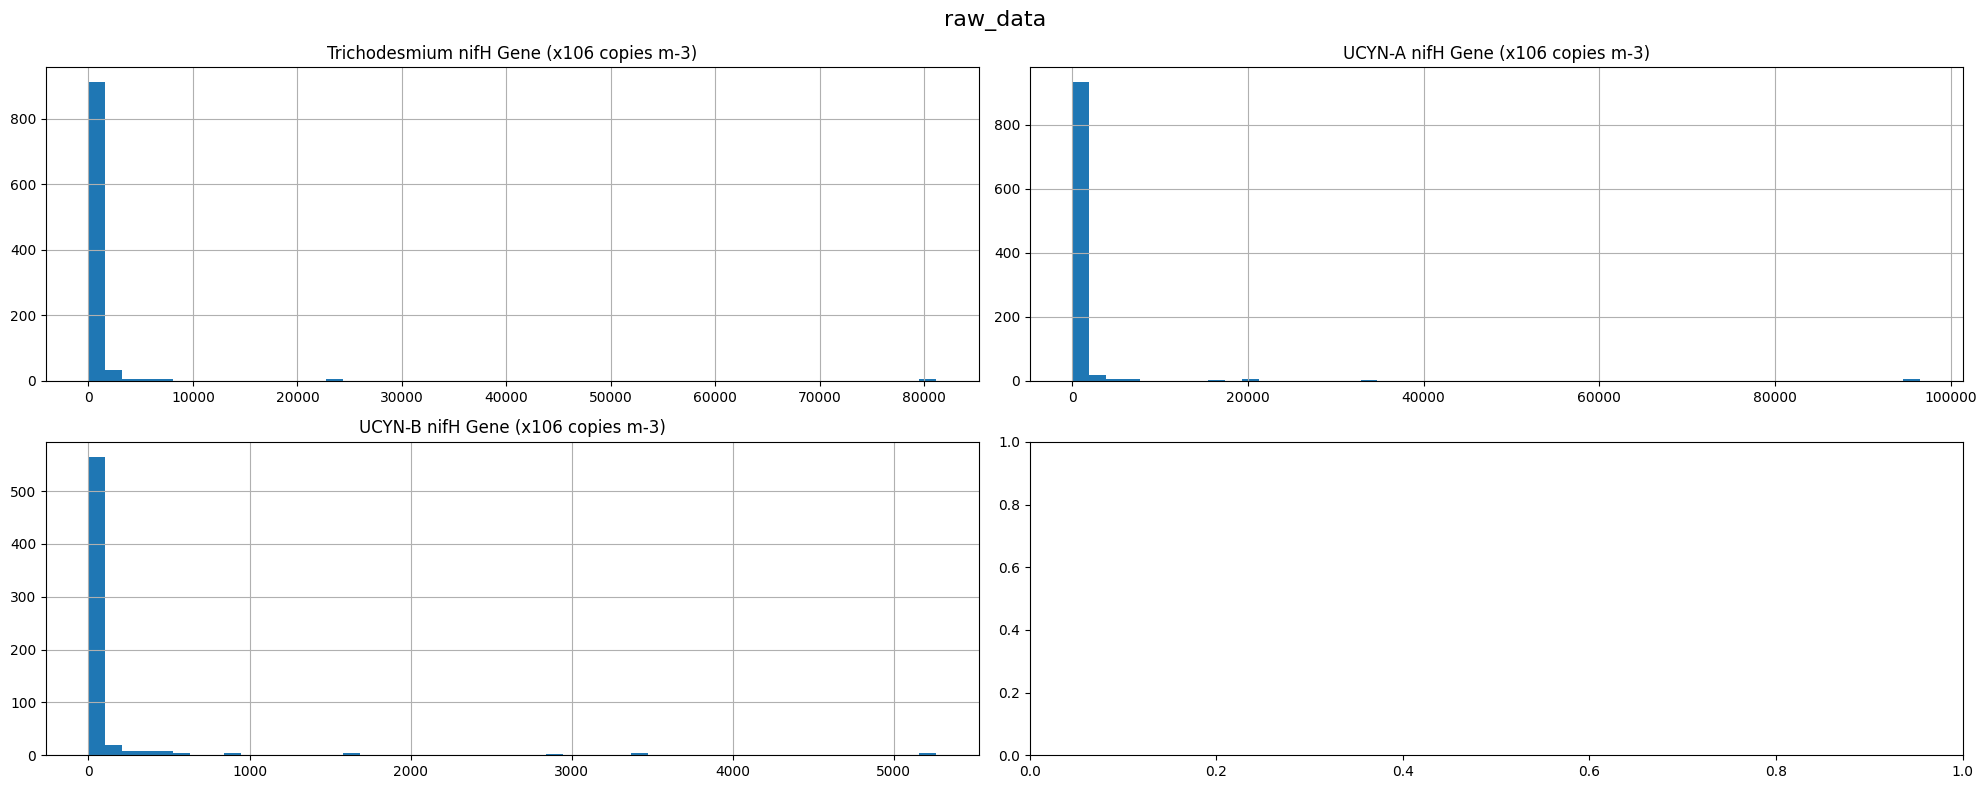

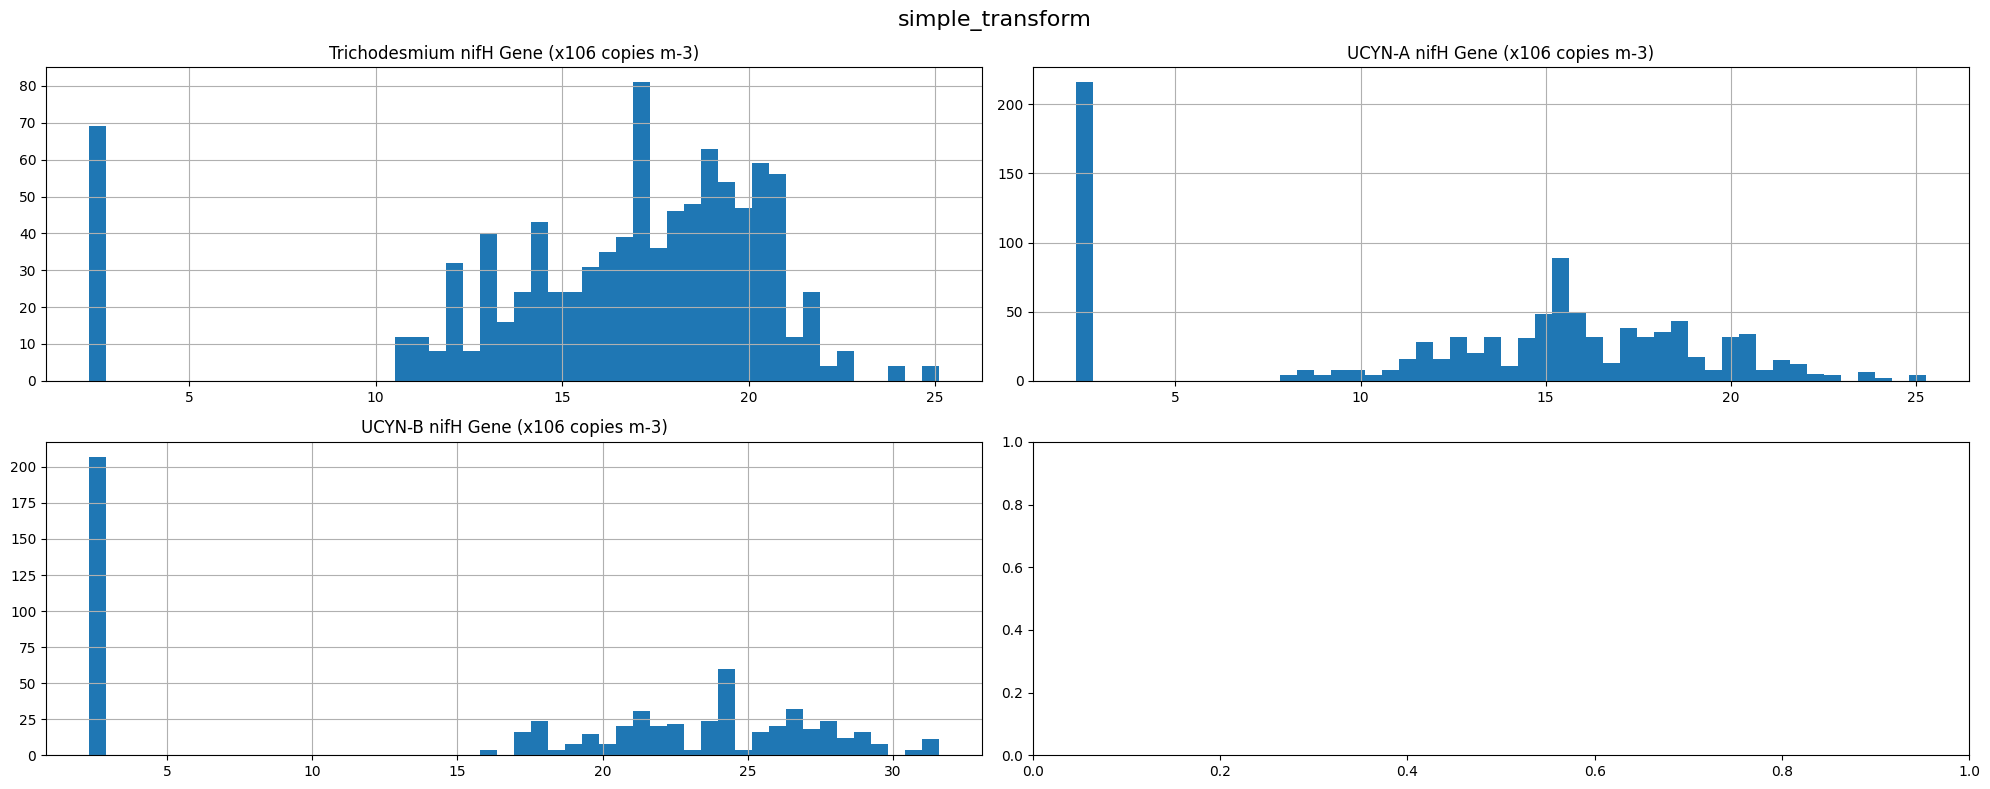

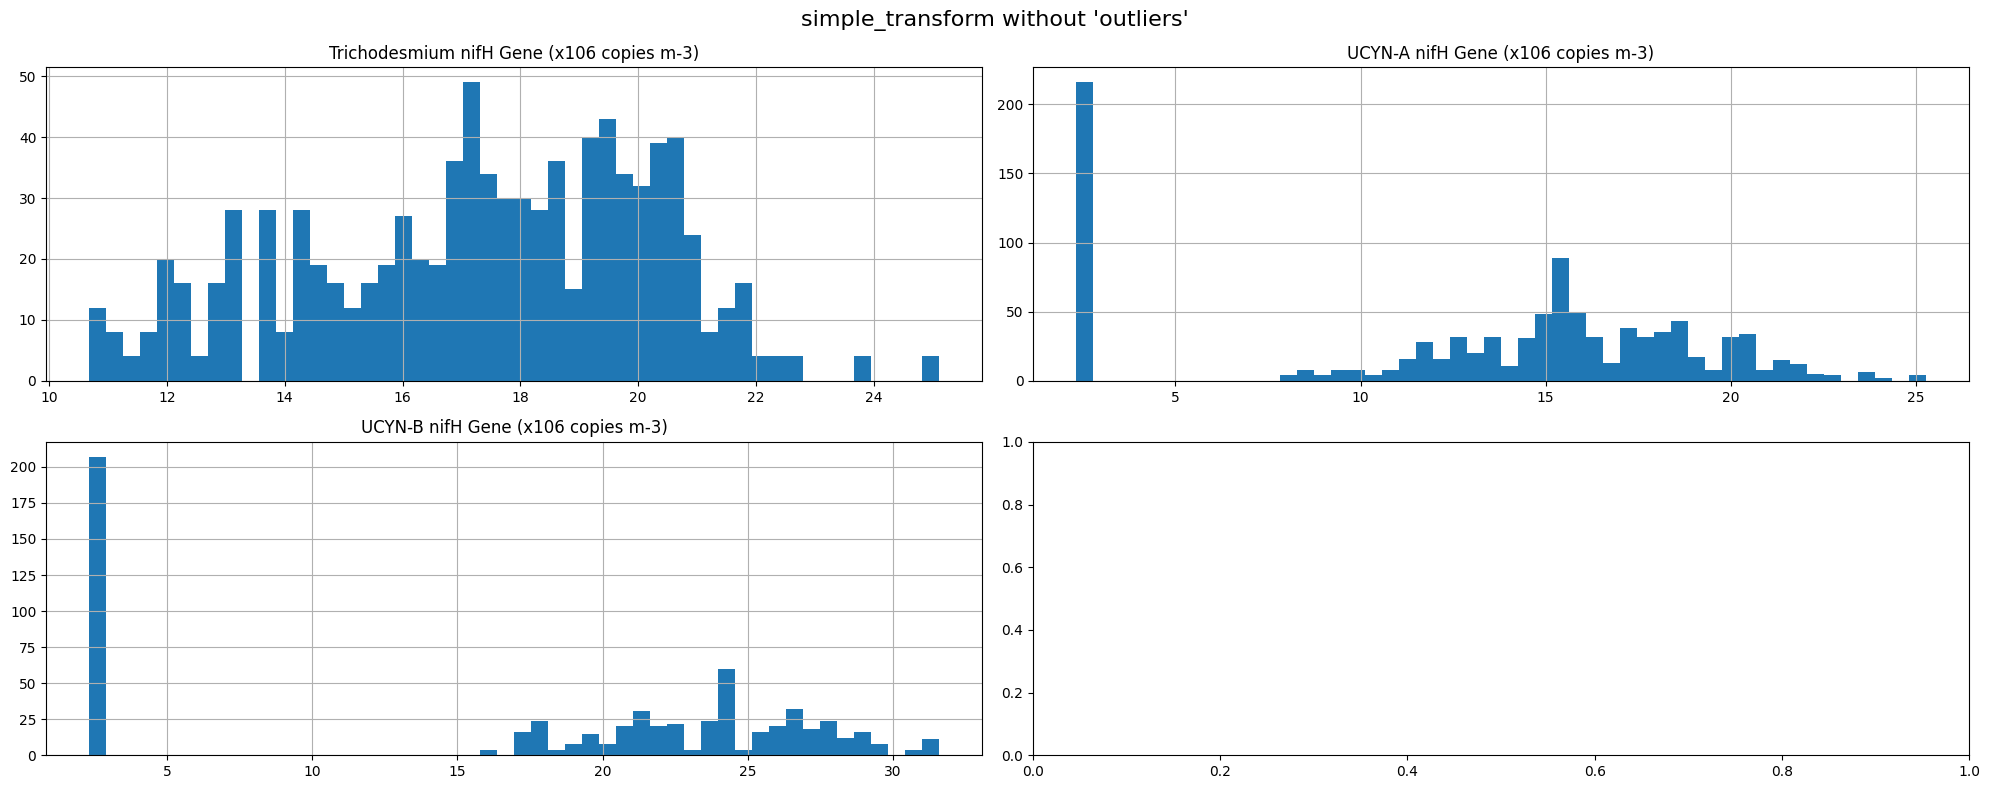

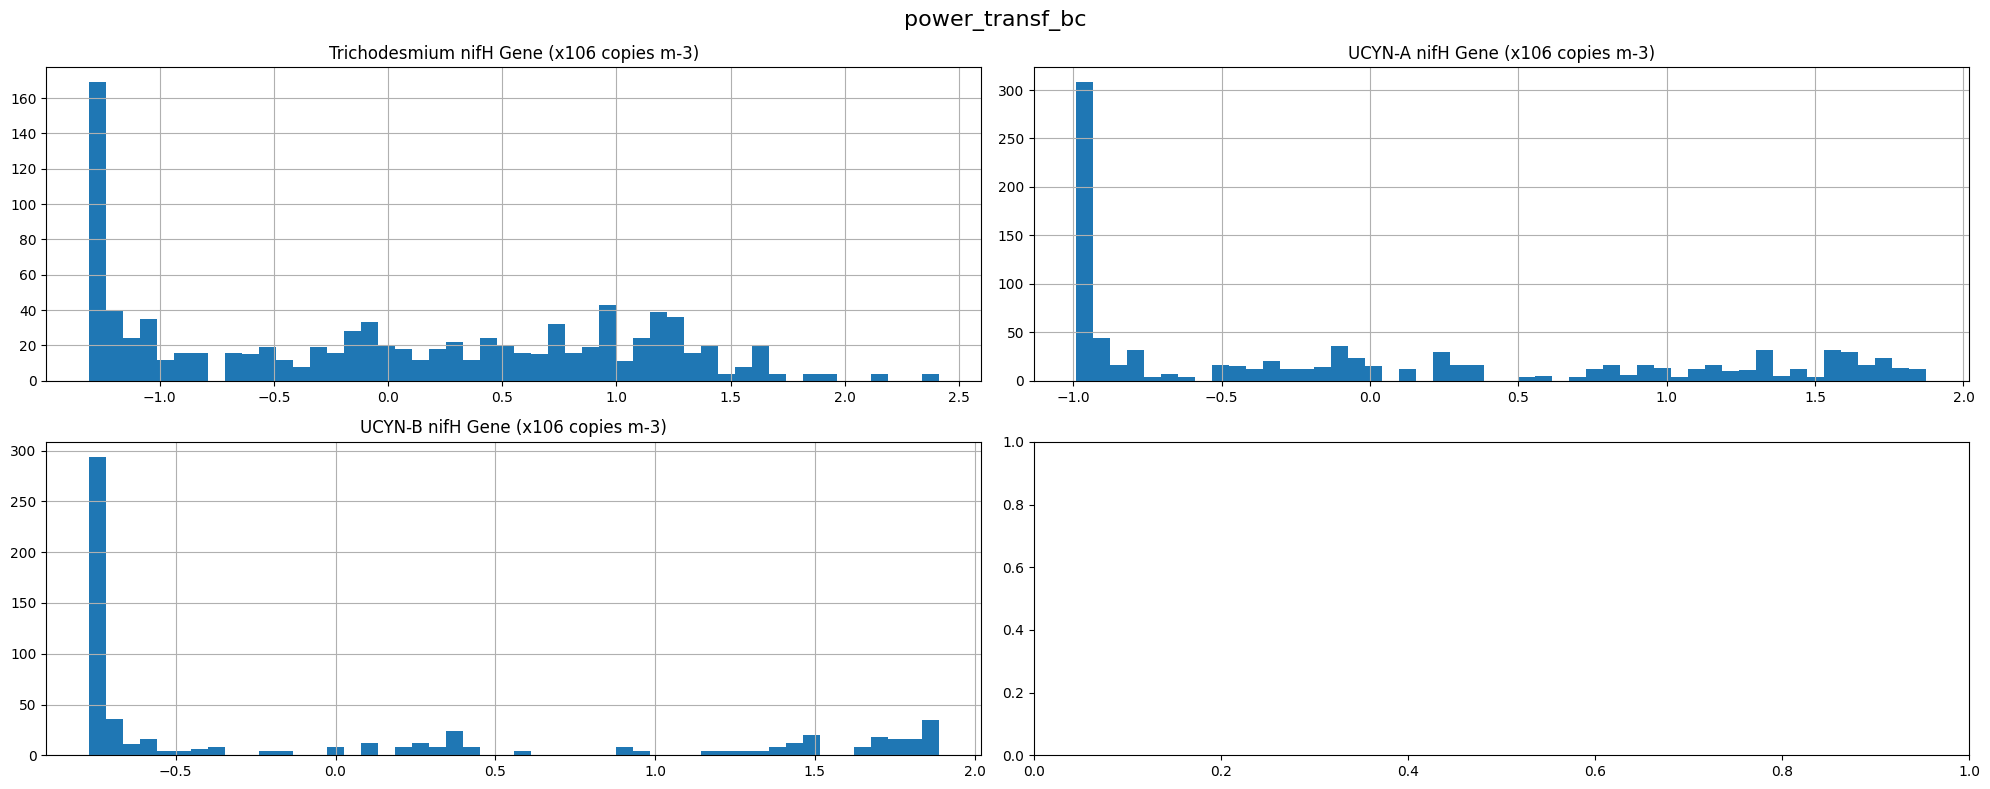

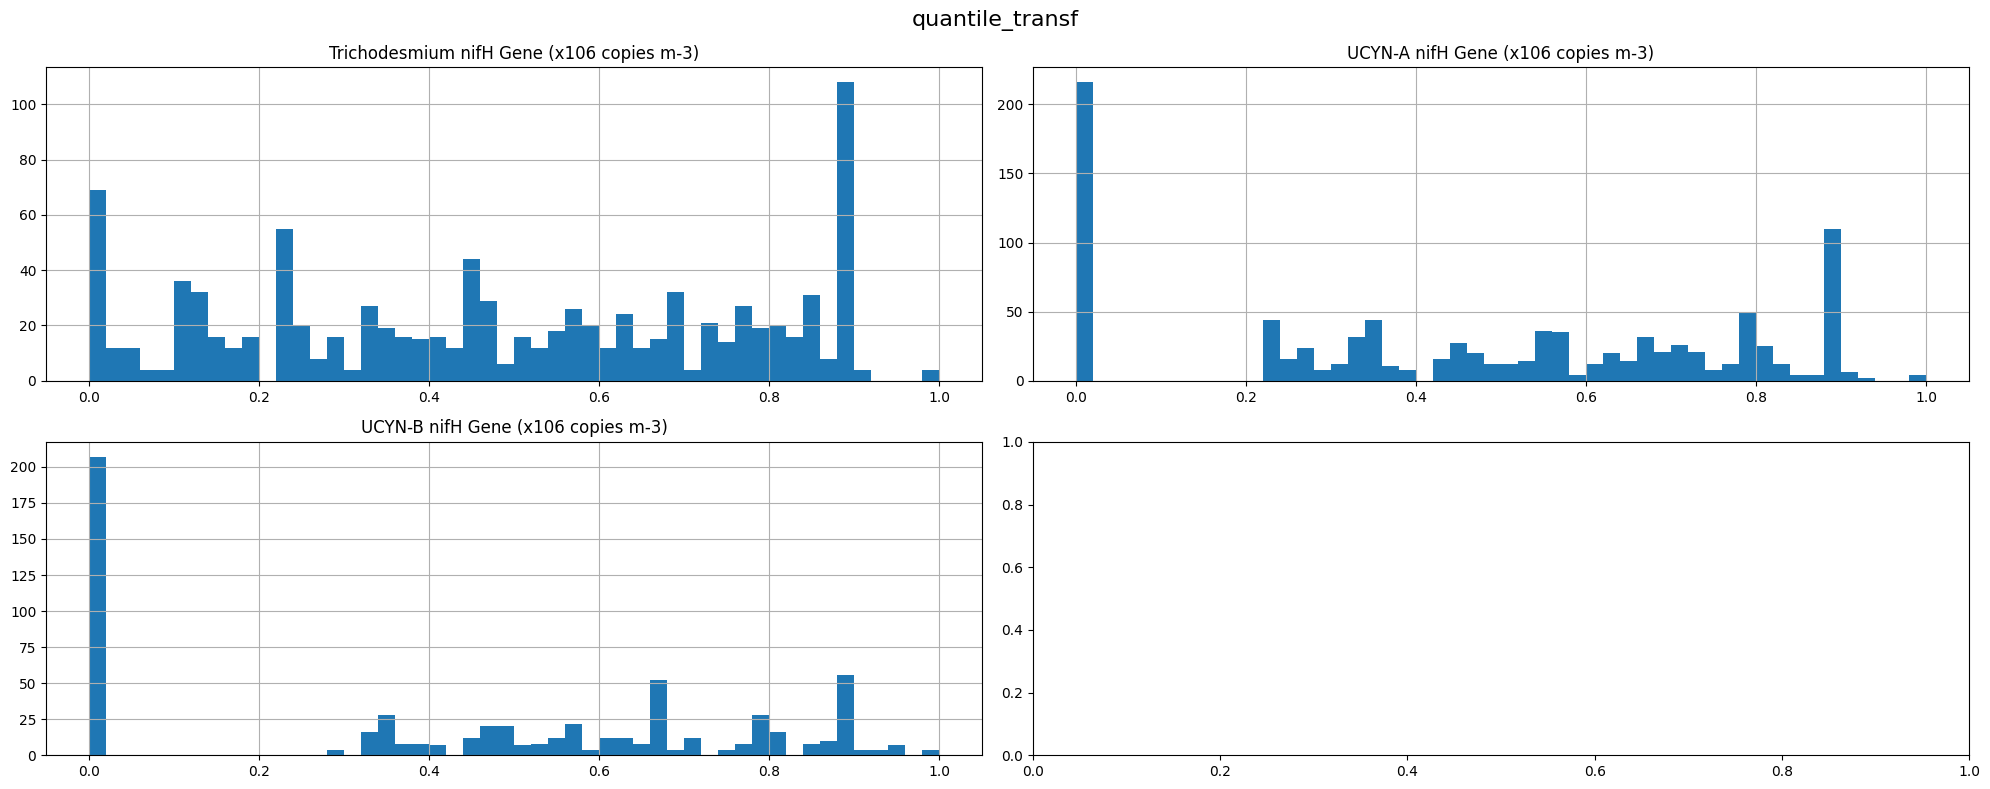

In [347]:
for name, dataset in datasets.items():
    histCols(y_columns, dataset, suptitle=name)

## Train test split

In order to verify that the data is actually generalizable and that the model can preditct on data it has never seen before we need to test it on such data that we set aside before training.

The data structure is the following:

```
training data:
{                                                         
    "name": {                                        
        "feature":{X_train, X_test, y_train, y_test}    
        "feature1":{X_train, X_test, y_train, y_test}   
        "feature2":{X_train, X_test, y_train, y_test}   
    }                                                   
    "name2": {                                          
        ...                                             
    }                                                      
}                                                       
```

In [348]:
from sklearn.model_selection import train_test_split

training_data = dict()

for name, dataset in datasets.items():
    training_data[name]=dict()
    for feature in y_columns:
        #we filter the data by the feature before splitting
        temp_ds = getData([feature], dataset)
        X_train, X_test, y_train, y_test = train_test_split(temp_ds[x_columns], temp_ds[y_columns], test_size=0.2, random_state=42)

        #we store the split data
        temp_dict = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test
        }

        #add results to the dictionary
        training_data[name][feature] = temp_dict

## Storing test results
In order to compare, store and visualize testing results we need a pandas dataframe

In [349]:
test_scores = pd.DataFrame(columns=["dataset name", "feature", "model","train_score","test_score"])

## Functions for testing different models

Training a given model on all datasets and storing the results in a common dataframe.

In [350]:
def try_model_on_all(model, model_name):
    for name in paths.keys():
        print("DATASET TEST: {0}".format(name))
        for feature in y_columns:
            print("FEATURE: {0}".format(feature))
            data = training_data[name][feature]
            X_train = data["X_train"]
            y_train = data["y_train"][feature]

            #model is trained
            train_model(model, X_train=X_train, y_train=y_train, model_name=model_name)

            train_score = score_model(model, X_train, data["y_train"], name, feature)
            test_score = score_model(model, data["X_test"], data["y_test"], name, feature)

            print("")
            ## we save the final results:
            test_scores.loc[test_scores.shape[0]]=[name, feature, model_name, train_score, test_score]

        print("")

## Training a baseline model

For a good baseline we can consider using linear regression and just taking the mean. Likely neither will be great, but that is the point. We want to see that better more suited models can achieve higher results.

In [351]:
model = DummyModel()
model_name ="dummy model"

try_model_on_all(model, model_name)

DATASET TEST: raw_data
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model dummy model achieved RMSE score of 6078.037656839828 on train dataset

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model dummy model achieved RMSE score of 6310.283268263187 on train dataset

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model dummy model achieved RMSE score of 597.5153498432949 on train dataset


DATASET TEST: simple_transform
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model dummy model achieved RMSE score of 4.8349482524401255 on train dataset

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model dummy model achieved RMSE score of 6.504462978737 on train dataset

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model dummy model achieved RMSE score of 10.66671475851114 on train dataset


DATASET TEST: simple_transform without 'outliers'
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model dummy model achieved RMSE score of 2.9137232106557276 on train dataset

FEATURE: UCYN-A nifH Gene (

## Trying out more models

In [352]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model_name="Linear regression"

try_model_on_all(model, model_name)

DATASET TEST: raw_data
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Linear regression achieved RMSE score of 6036.277870614617 on train dataset

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Linear regression achieved RMSE score of 6243.589578833627 on train dataset

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model Linear regression achieved RMSE score of 574.7945043334265 on train dataset


DATASET TEST: simple_transform
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Linear regression achieved RMSE score of 4.653299615445691 on train dataset

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Linear regression achieved RMSE score of 6.069866622882167 on train dataset

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model Linear regression achieved RMSE score of 10.149493385490162 on train dataset


DATASET TEST: simple_transform without 'outliers'
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Linear regression achieved RMSE score of 2.8580233600530787 

In [353]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model_name="Random forest regressor"
try_model_on_all(model, model_name)

DATASET TEST: raw_data
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)


Model Random forest regressor achieved RMSE score of 2100.256477068275 on train dataset

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Random forest regressor achieved RMSE score of 2574.7846636272343 on train dataset

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model Random forest regressor achieved RMSE score of 183.18448956758397 on train dataset


DATASET TEST: simple_transform
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Random forest regressor achieved RMSE score of 1.0241582442771162 on train dataset

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Random forest regressor achieved RMSE score of 1.3717595005816934 on train dataset

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model Random forest regressor achieved RMSE score of 2.3063123720828127 on train dataset


DATASET TEST: simple_transform without 'outliers'
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Random forest regressor achieved RMSE score of 0.7037608195955942 on train dataset

FEATURE: U

In [354]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=4)
model_name="Decision tree regressor"
try_model_on_all(model, model_name)

DATASET TEST: raw_data
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 1680.9156592336178 on train dataset

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 1291.5957798448733 on train dataset

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 467.9076309838728 on train dataset


DATASET TEST: simple_transform
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 3.8206352772066325 on train dataset

FEATURE: UCYN-A nifH Gene (x106 copies m-3)


Model Decision tree regressor achieved RMSE score of 4.893743107735325 on train dataset

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 7.262926368551904 on train dataset


DATASET TEST: simple_transform without 'outliers'
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 2.3746355825034033 on train dataset

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 4.893743107735325 on train dataset

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 7.262926368551904 on train dataset


DATASET TEST: power_transf_bc
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 0.8464319052513302 on train dataset

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 0.8039899425651647 on train dataset

FEATURE: UCYN-

## Visualizing the results

In [355]:
test_scores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   dataset name  60 non-null     object 
 1   feature       60 non-null     object 
 2   model         60 non-null     object 
 3   train_score   60 non-null     float64
 4   test_score    60 non-null     float64
dtypes: float64(2), object(3)
memory usage: 2.8+ KB


In [356]:
test_scores.head()

,dataset name,feature,model,train_score,test_score
0,raw_data,Trichodesmium nifH Gene (x106 copies m-3),dummy model,6078.037657,912.935120
1,raw_data,UCYN-A nifH Gene (x106 copies m-3),dummy model,6310.283268,7415.486133
2,raw_data,UCYN-B nifH Gene (x106 copies m-3),dummy model,597.515350,332.742019
3,simple_transform,Trichodesmium nifH Gene (x106 copies m-3),dummy model,4.834948,4.624623
4,simple_transform,UCYN-A nifH Gene (x106 copies m-3),dummy model,6.504463,6.063252


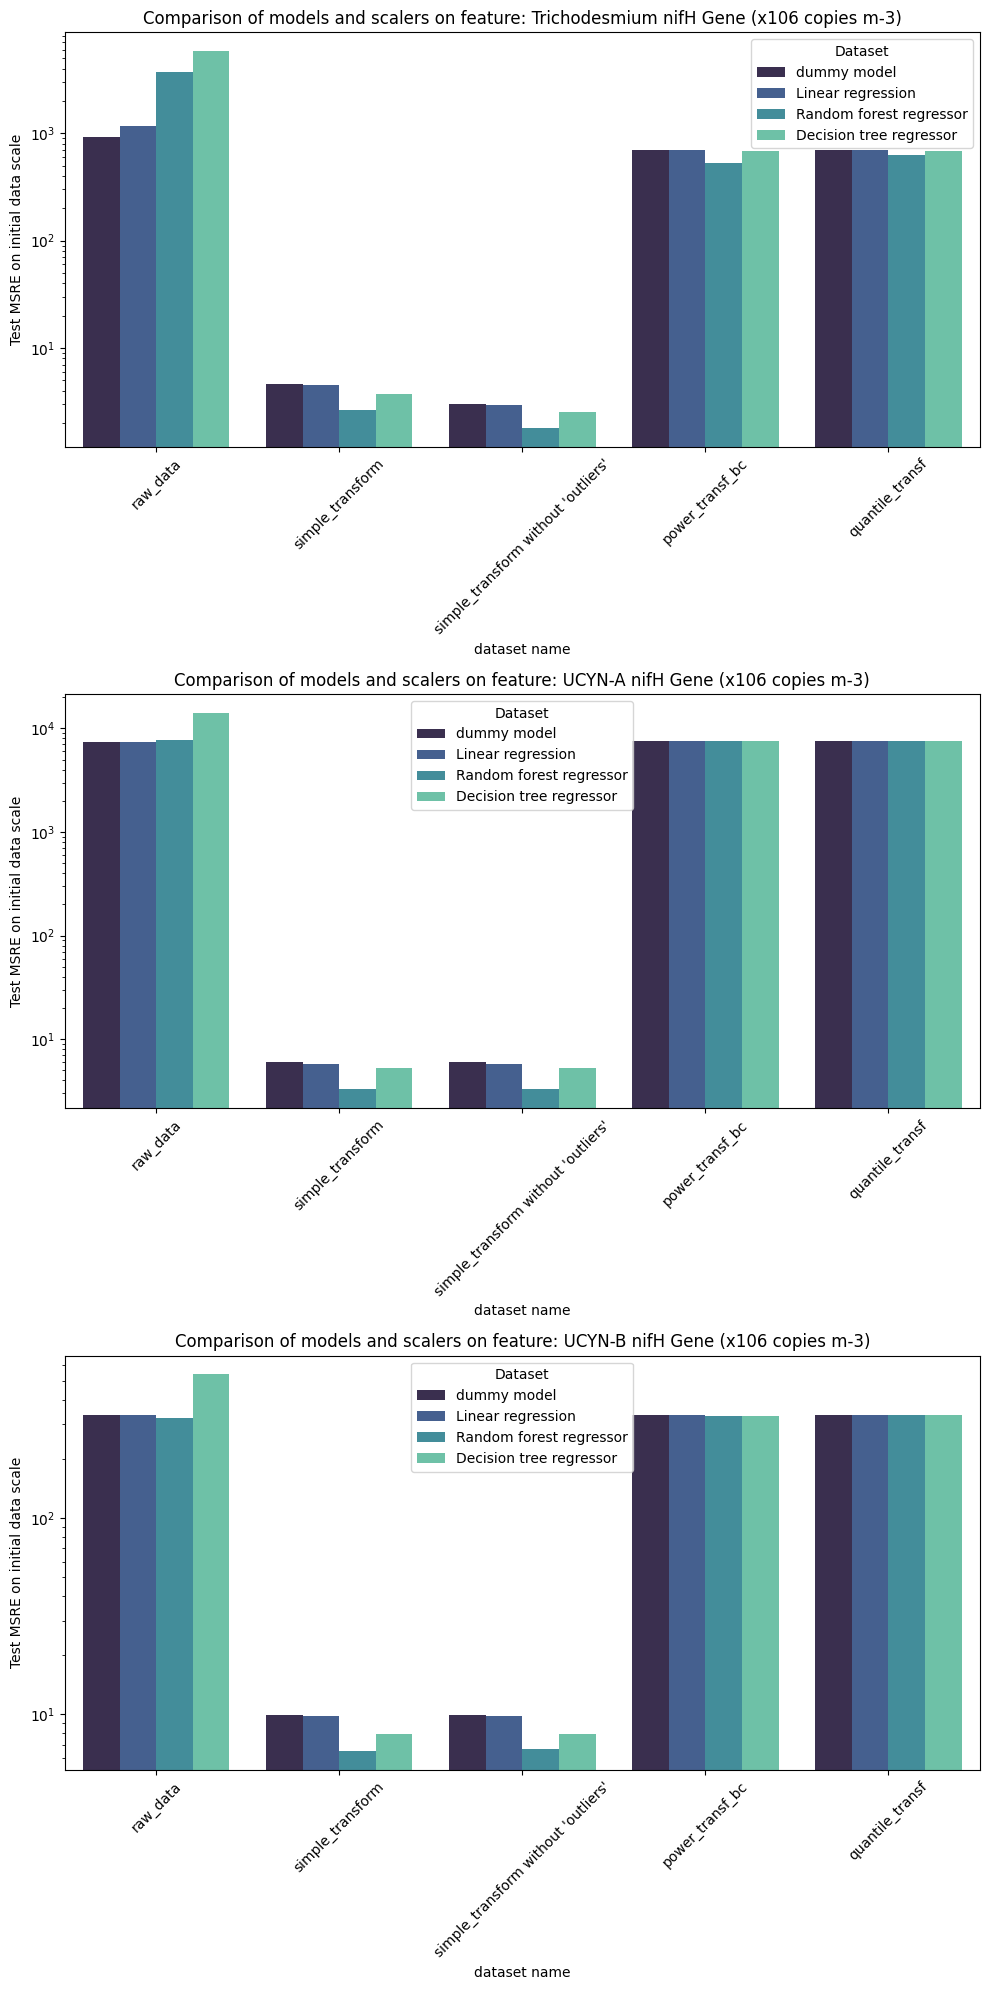

In [357]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 20))
axes = axes.flatten()

for i, feature in enumerate(y_columns):
    ax=axes[i]
    
    ##we plot a single feature
    subset = test_scores[test_scores['feature'] == feature]

    sns.barplot(
        data=subset,
        x='dataset name',
        y='test_score',
        hue='model',
        palette='mako',
        ax=ax
    )

    ax.set_title('Comparison of models and scalers on feature: {0}'.format(feature))
    ax.set_ylabel('Test MSRE on initial data scale')
    ax.set_yscale('log')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Dataset')
plt.tight_layout()
plt.show()

## Linear regression analysis

One of the tasks to me was to train a linear regression model and record/display the coefficients. So, this is what the next few cells do.

In [358]:
lin_set_name = "simple_transform"
data = training_data[name]

coef_df = pd.DataFrame(columns=x_columns)

for feature in y_columns:
    #we pick the data related to the feature
    data_ft = data[feature]

    #the training data
    X_train = data_ft["X_train"]
    y_train = data_ft["y_train"][feature]

    model = LinearRegression().fit(X_train, y_train)
    coef = model.coef_
    row = coef_df.shape[0]
    
    coef_df.loc[row] =  coef

coef_df["feature"] = y_columns
df_melted = coef_df.melt(id_vars='feature', var_name='variable', value_name='value')

df_melted.head()

,feature,variable,value
0,Trichodesmium nifH Gene (x106 copies m-3),O2_knn,0.297730
1,UCYN-A nifH Gene (x106 copies m-3),O2_knn,0.026863
2,UCYN-B nifH Gene (x106 copies m-3),O2_knn,0.078099
3,Trichodesmium nifH Gene (x106 copies m-3),T_knn,0.263709
4,UCYN-A nifH Gene (x106 copies m-3),T_knn,-0.660731


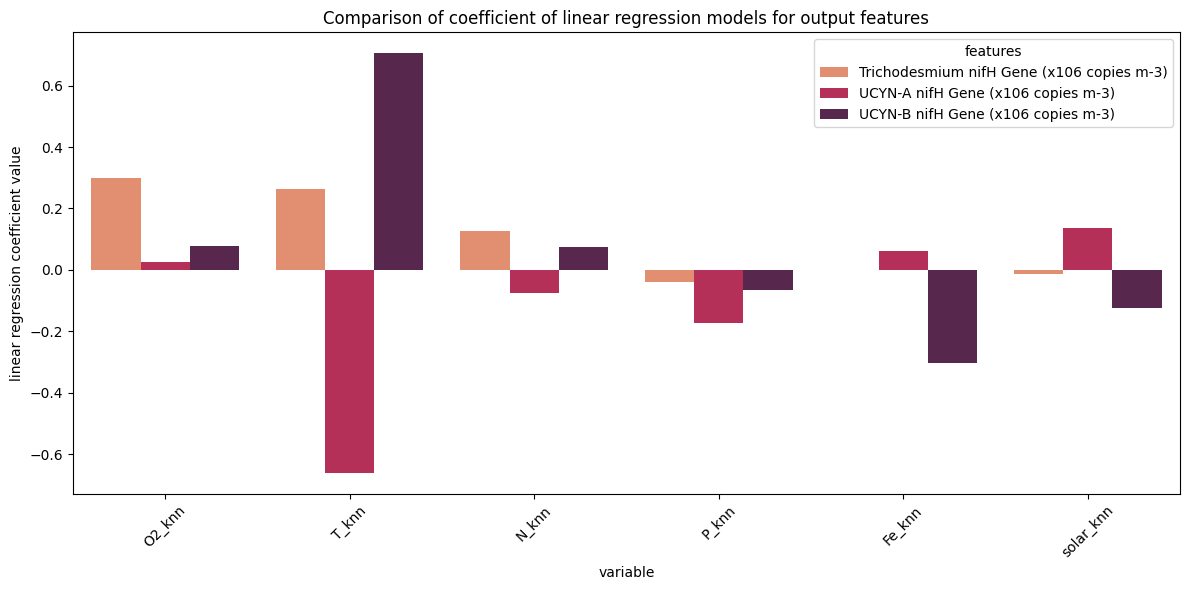

In [359]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_melted,
    x='variable',
    y='value',
    hue='feature',
    palette='rocket_r',
)

plt.title("Comparison of coefficient of linear regression models for output features")
plt.ylabel('linear regression coefficient value')
plt.tick_params(axis='x', rotation=45)
plt.legend(title='features')
plt.tight_layout()
plt.show()

## Conclusion

### Dataset(scaler-transform) choice:
So far the most crucial factor seems to be the dataset used. Despite the correlation suggesting one type of picutre, where UCYN should have the best predictions on scikit scalers, a simple transform set has the lowest error rates accross the board.


### Model choice:
It appears as though differences between different models aren't that great, but the rfr has by far the lowest erros everywhere. It should be noted here that not having a great difference regardless of the model might mean that due to data being so skewed predicting the average is a surprisingly good strategy for any model.


In [360]:
name = "simple_transform"
#name="quantile_transf"
data = training_data[name]

final_models = dict()

for feature in y_columns:
    #we pick the data related to the feature
    data_ft = data[feature]

    #the training data
    X_train = data_ft["X_train"]
    y_train = data_ft["y_train"][feature]

    model = RandomForestRegressor().fit(X_train, y_train)
    final_models[feature]=model

## Map projections
We obtained the prelimiary testing results. Now we can load back the data of the environmental variables and try to predict the ocean data for each feature. Here we use the final model set and project what the data should be according to the models on the rest of the globe.

In [361]:
env_data = pd.read_csv("./csv/filled/env_data_all_fill.csv")[x_columns+["LONGITUDE", "LATITUDE"]]

coordinates = env_data[["LONGITUDE", "LATITUDE"]].copy()
env_data=env_data[x_columns]

#this is to make sure the scaler works
env_data_rows = env_data.shape[0]
for col in y_columns:
    env_data[col] = np.ones(env_data_rows)

env_data_array = transformers[name].transform(env_data)
env_data_df = pd.DataFrame(env_data_array, columns=env_data.columns)[x_columns]

env_data_df.info()

applying the transform
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41114 entries, 0 to 41113
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   O2_knn     41114 non-null  float64
 1   T_knn      41114 non-null  float64
 2   N_knn      41114 non-null  float64
 3   P_knn      41114 non-null  float64
 4   Fe_knn     41114 non-null  float64
 5   solar_knn  41114 non-null  float64
dtypes: float64(6)
memory usage: 1.9 MB


### Data is predicted based on environmental factors

In [362]:
predictions_df = pd.DataFrame()

#we predict the data and join back the coordinates
for feature in y_columns:
    predictions = model.predict(env_data_df)
    predictions_df[feature]=predictions

### Inverse transform

In [363]:
predictions_df_invtr = transofrm_back(name, pd.concat([env_data_df, predictions_df], axis=1))

predictions_df_invtr_cr = pd.concat([coordinates.copy(), predictions_df_invtr], axis=1)
predictions_df_invtr_cr.describe()

,LONGITUDE,LATITUDE,O2_knn,T_knn,N_knn,P_knn,Fe_knn,solar_knn,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,41114.000000,41114.000000,41114.000000,41114.000000,41114.000000,41114.000000,41114.000000,41114.000000,41114.000000,41114.000000,41114.000000
mean,-9.973586,-2.295568,19.378320,16.866416,7.014243,12.767731,4.931339,150.852539,14.553021,14.553021,14.553021
std,108.690952,46.559775,0.230665,0.553183,2.305131,1.258098,1.386393,29.141026,5.460466,5.460466,5.460466
min,-180.000000,-78.000000,18.448841,15.881466,2.302585,2.302585,2.302585,73.144280,2.302585,2.302585,2.302585
25%,-108.000000,-42.000000,19.153761,16.322403,5.007327,11.971468,4.102528,126.923660,11.764905,11.764905,11.764905
50%,-20.000000,-8.000000,19.342360,17.063269,7.102790,12.834708,5.252354,152.354700,13.001257,13.001257,13.001257
75%,84.000000,32.000000,19.604533,17.382961,9.186436,13.790210,5.996435,178.062440,18.106357,18.106357,18.106357
max,178.000000,90.000000,19.946974,17.500374,10.436153,14.959046,8.096321,195.219760,31.073457,31.073457,31.073457


### Maps

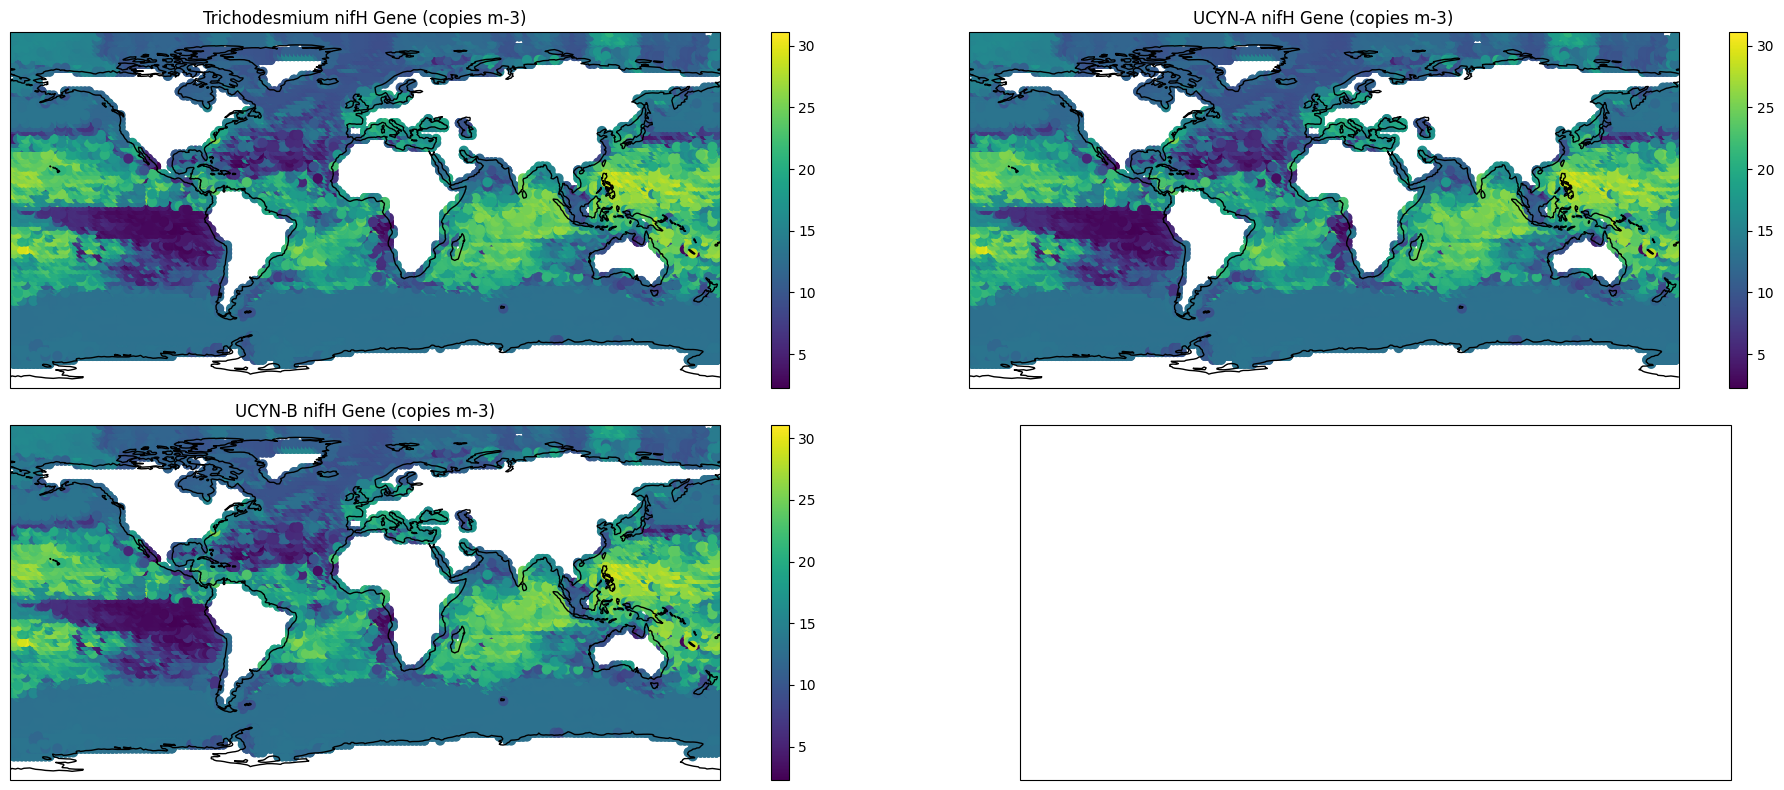

In [364]:
plotColsOnMap(y_columns, predictions_df_invtr_cr)

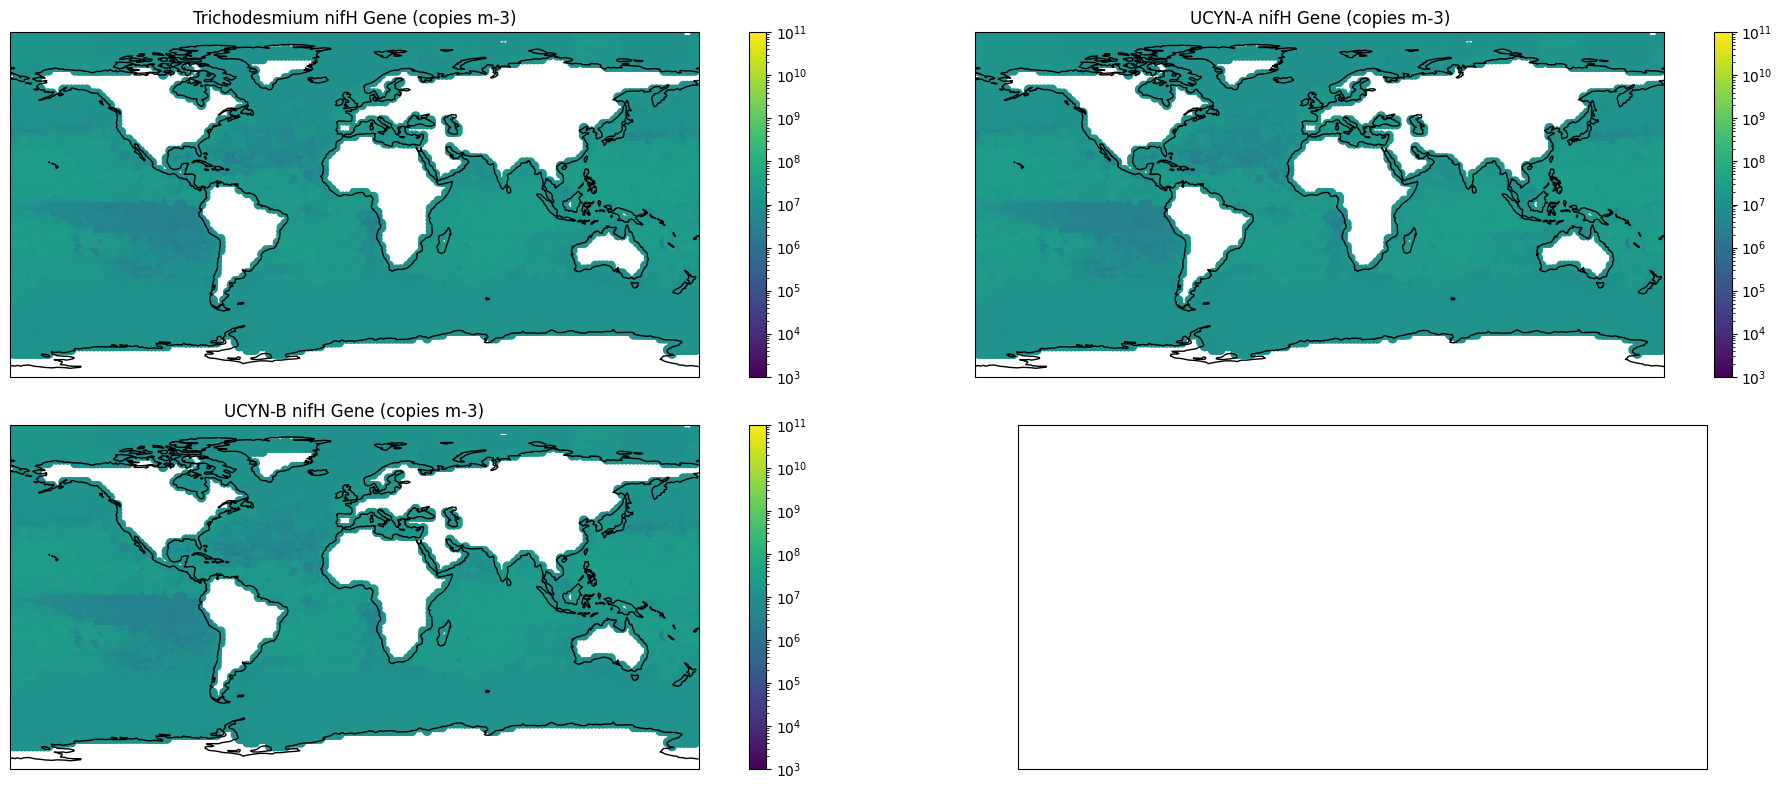

In [365]:
plotColsOnMap(y_columns, predictions_df_invtr_cr, True, 10**6)